In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
!pip install -qq git+https://github.com/udesa-vision/i308-utils.git
from i308_utils import imshow, show_images

CALIBRACION DE LA CAMARA.

In [10]:
# Definición del checkerboard

checkerboard = (10, 7)
square_size_mm = 24.2


In [11]:
from utils.calib import board_points

# creamos los puntos del mundo del objeto checkerboard
checkerboard_world_points_mm = board_points(checkerboard) * square_size_mm


In [12]:
import glob, os

directory = os.path.join("datasets", "stereo_budha_charuco", "calib")
left_files_pattern = "*left*.jpg"
right_files_pattern = "*right*.jpg"

def numeric_sort(file_name):
    return int(file_name.split("_")[-1].split(".")[0])

left_file_names = sorted(
    glob.glob(
        os.path.join(directory, left_files_pattern)
    ),
    key=numeric_sort
)

right_file_names = sorted(
    glob.glob(
        os.path.join(directory, right_files_pattern)
    ),
    key=numeric_sort
)

num_left = len(left_file_names)
num_right = len(right_file_names)

if  num_left != num_right:
    raise Exception(f"the number of files (left {num_left} / right{num_right}) doesn't match")

In [ ]:
import cv2

image_size = None
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

world_points = []
left_images = []
right_images = []
left_images_points = []
right_images_points = []

for left_file_name, right_file_name in zip(
    left_file_names, right_file_names
):

    print("processing", left_file_name, right_file_name)

    # read left and right images
    left_image = cv2.imread(left_file_name, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_file_name, cv2.IMREAD_GRAYSCALE)

    # get the images sizes
    left_size = (left_image.shape[1], left_image.shape[0])
    right_size = (right_image.shape[1], right_image.shape[0])

    # checks that images sizes match
    if left_size != right_size:
        raise Exception(f"left and right images sizes differ: left {left_size} / right {right_size}")
        
    if image_size is None:
        # remembers the images size
        image_size = left_size
    else:
        if image_size != left_size:
            raise Exception(f"there are images with different sizes: {image_size} vs {left_size}")

    # finds the checkerboard in each image
    left_found, left_corners = cv2.findChessboardCorners(left_image, checkerboard)
    right_found, right_corners = cv2.findChessboardCorners(right_image, checkerboard)

    if not left_found or not right_found:
        print("warning, checkerboard was not found")
        print("  left found:", left_found)
        print("  right found:", right_found)
        continue

 
    corners_left = cv2.cornerSubPix(left_image, left_corners, (7, 7), (-1,-1), criteria)
    corners_right = cv2.cornerSubPix(right_image, right_corners, (7, 7), (-1,-1), criteria)

    # acumulo las imagenes
    left_images.append(left_image)
    right_images.append(right_image)

    # acumulo los corners detectados
    left_images_points.append(left_corners)
    right_images_points.append(right_corners)

    # acumulo los puntos del mundo
    world_points.append(checkerboard_world_points_mm)



processing datasets\stereo_budha_charuco\calib\left_1.jpg datasets\stereo_budha_charuco\calib\right_1.jpg
processing datasets\stereo_budha_charuco\calib\left_2.jpg datasets\stereo_budha_charuco\calib\right_2.jpg
processing datasets\stereo_budha_charuco\calib\left_3.jpg datasets\stereo_budha_charuco\calib\right_3.jpg
processing datasets\stereo_budha_charuco\calib\left_4.jpg datasets\stereo_budha_charuco\calib\right_4.jpg
processing datasets\stereo_budha_charuco\calib\left_5.jpg datasets\stereo_budha_charuco\calib\right_5.jpg
processing datasets\stereo_budha_charuco\calib\left_6.jpg datasets\stereo_budha_charuco\calib\right_6.jpg
processing datasets\stereo_budha_charuco\calib\left_7.jpg datasets\stereo_budha_charuco\calib\right_7.jpg
processing datasets\stereo_budha_charuco\calib\left_8.jpg datasets\stereo_budha_charuco\calib\right_8.jpg
processing datasets\stereo_budha_charuco\calib\left_9.jpg datasets\stereo_budha_charuco\calib\right_9.jpg
processing datasets\stereo_budha_charuco\calib

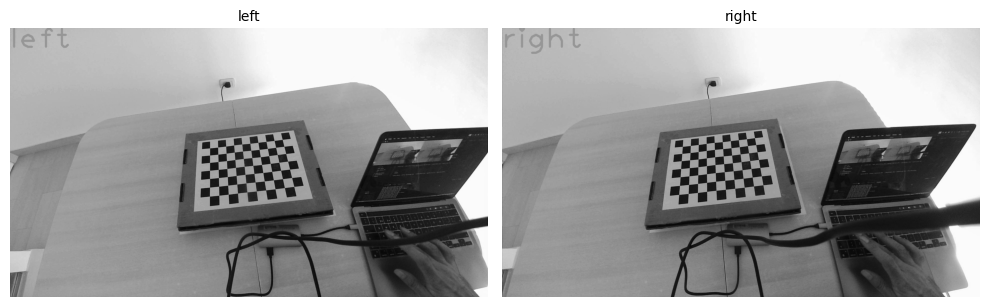

In [14]:
show_images([
    left_images[14], right_images[14]
], ['left', 'right'])

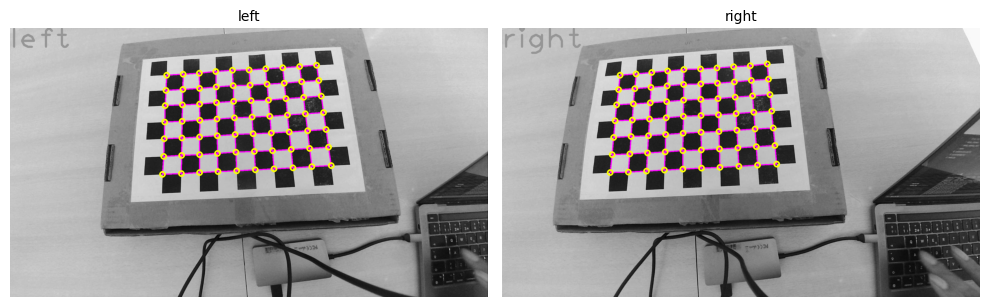

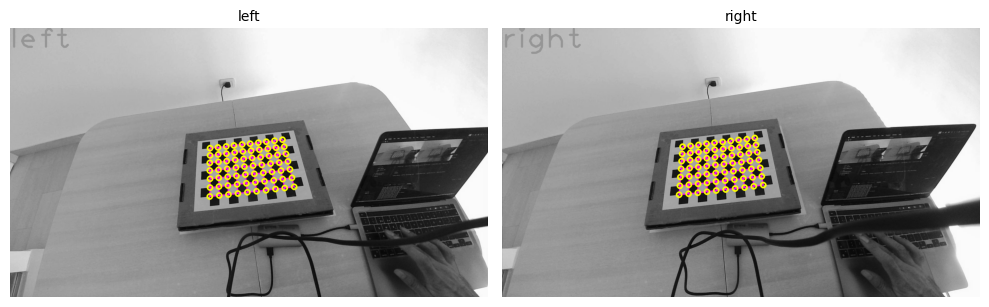

In [15]:
# grafiquemos algunos checkerboards
# y sus detecciones de corners
#  para verificar que lo que encontró está ok:

import utils.calib as calib
some_images_indices = [5, 14]

draw_settings = {
    "corner_radius": 10,
    "corner_thickness": 5,
    "line_thickness": 4
}
for i in some_images_indices:

    left_img, right_img = left_images[i], right_images[i]
    left_corners, right_corners = left_images_points[i], right_images_points[i]

    show_left = cv2.cvtColor(left_img, cv2.COLOR_GRAY2BGR)
    show_right = cv2.cvtColor(right_img, cv2.COLOR_GRAY2BGR)


    calib.draw_checkerboard(show_left, checkerboard, left_corners, True, **draw_settings)
    calib.draw_checkerboard(show_right, checkerboard, right_corners, True, **draw_settings)
    

    show_images([show_left, show_right], ["left", "right"])

In [16]:
# Calibramos Stereo

print("Calibrating Stereo")
print("num images:", len(left_images_points))

err, left_K, left_dist, right_K, right_dist, R, T, E, F = cv2.stereoCalibrate(
    world_points, 
    left_images_points, 
    right_images_points, 
    None, 
    None, 
    None, 
    None, 
    image_size, 
    flags=0
)

Calibrating Stereo
num images: 20


In [17]:
from utils.calib import np_print

to_print = [

    "# Left camera Intrinsics:",
    ("left_K", left_K),
    ("left_dist", left_dist),

    "# Right camera Intrinsics:",
    ("right_K", right_K),
    ("right_dist", right_dist),

    "# Rotation:",
    ("R", R),

    "# Translation:",
    ("T", T),
    
    "# Essential Matrix:",
    ("E", E),
    
    "# Fundamental Matrix:",
    ("F", F),
        
]

In [18]:
print("# STEREO CALIBRATION")
for line in to_print:

    if isinstance(line, str):   
        print(line)
    else:
        var_name, np_array = line
        print(f"{var_name} = {np_print(np_array)}\n")

# STEREO CALIBRATION
# Left camera Intrinsics:
left_K = np.array([
	[   600.567,	     0.000,	   950.832],
	[     0.000,	   601.170,	   540.553],
	[     0.000,	     0.000,	     1.000]
])

left_dist = np.array([
	[  0.016181,	 -0.032403,	 -0.001841,	 -0.000122,	  0.005916]
])

# Right camera Intrinsics:
right_K = np.array([
	[   600.364,	     0.000,	   951.697],
	[     0.000,	   600.968,	   527.345],
	[     0.000,	     0.000,	     1.000]
])

right_dist = np.array([
	[  0.016353,	 -0.032117,	 -0.001719,	  0.000826,	  0.005614]
])

# Rotation:
R = np.array([
	[     1.000,	     0.001,	     0.001],
	[    -0.001,	     1.000,	     0.010],
	[    -0.001,	    -0.010,	     1.000]
])

# Translation:
T = np.array([
	[-59.957119],
	[  0.206578],
	[  0.311046]
])

# Essential Matrix:
E = np.array([
	[    -0.000,	    -0.313,	     0.203],
	[     0.228,	    -0.619,	    59.954],
	[    -0.153,	   -59.954,	    -0.619]
])

# Fundamental Matrix:
F = np.array([
	[     0.000,	     0.000,	    -0.045],
	[    -0.0

In [19]:
# serializamos los resultados en un pickle
import pickle

calibration_results = {
    'left_K': left_K,
    'left_dist': left_dist,
    'right_K': right_K,
    'right_dist': right_dist,
    'R': R,
    'T': T,
    'E': E,
    'F': F,
    'image_size': image_size,
}

calibration_file = os.path.join("datasets","stereo_budha_charuco", "stereo_calibration.pkl")
with open(calibration_file, "wb") as f:
    f.write(pickle.dumps(calibration_results))
        


RECTIFICACION

In [20]:
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist, right_K, right_dist, image_size, R, T, alpha=0
)

In [21]:
# calculemos los mapas de des-distorsión-rectificación:

left_map_x, left_map_y = cv2.initUndistortRectifyMap(left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1)

In [22]:
# Qué pinta tienen estos mapas?
# chequeemos el shape, debería coincidir con image_size
left_map_x.shape

(1080, 1920)

In [23]:
# Qué valores contiene?
# en este caso son floats, por lo que se necesitará alguna forma de interpolación
left_map_x[0:3, 0:3]

array([[71.92957 , 72.81671 , 73.702545],
       [71.93458 , 72.82093 , 73.705986],
       [71.939156, 72.82474 , 73.709015]], dtype=float32)

In [24]:
# tomemos un par estéreo
image_index = 5

left_image = left_images[image_index]
right_image = right_images[image_index]

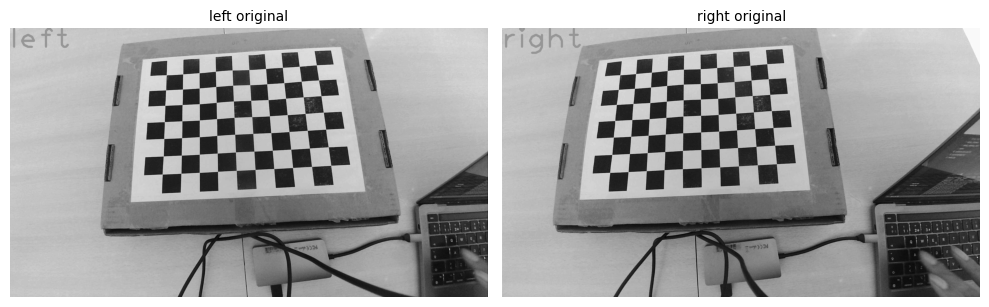

In [25]:
# muestro las imagenes:
show_images([
    left_image, right_image
], [
    "left original", "right original"
])


In [26]:
# aplicamos des-distorsion + rectificación, con los mapas que calculamos ateriormente
left_image_rectified = cv2.remap(left_image, left_map_x, left_map_y, cv2.INTER_LINEAR)
right_image_rectified = cv2.remap(right_image, right_map_x, right_map_y, cv2.INTER_LINEAR)

In [27]:
import numpy as np

# Ejemplo, para saber qué valor poner en la posición (i,j) de la imagen destino,
# a cuál píxel en la imagen original tendríamos que ir buscar?
x_dest, y_dest = 321, 123

x_ori = left_map_x[y_dest, x_dest]
y_ori = left_map_y[y_dest, x_dest]

x_ori = int(np.round(x_ori))
y_ori = int(np.round(y_ori))

print(f"using nearest neighbor interpolation, I_dest[{y_dest}, {x_dest}] = I_ori[{y_ori}, {x_ori}]")

print(left_image[y_ori, x_ori])
print(left_image_rectified[y_dest, x_dest])


using nearest neighbor interpolation, I_dest[123, 321] = I_ori[146, 330]
194
194


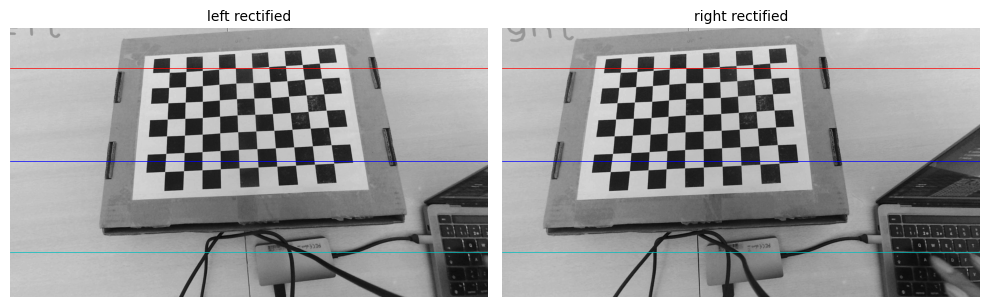

In [28]:
# muestro las imagenes stereo-rectificadas
# observar el vertice de la caja, de la notebook, y del cuaderno. 
# coinciden perfectamente en y.
from matplotlib import pyplot as plt 

fig, axes = show_images([
    left_image_rectified, right_image_rectified
], [
    "left rectified", "right rectified"
], show=False)

for y, c in zip([160, 533, 900], ['r', 'b', 'c']):
    axes[0].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
    axes[1].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
plt.show()

In [ ]:

stereo_maps = {

    # undistorting maps
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,

    # add also rectifying info:
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,

}

stereo_maps_file = os.path.join("datasets","stereo_budha_charuco", "stereo_rectification_maps.pkl")
with open(stereo_maps_file, "wb") as f:
    f.write(pickle.dumps(stereo_maps))
        

In [30]:
import os

left_image_file = os.path.join("datasets","stereo_budha_charuco", "captures", "left_10.jpg")
right_image_file = os.path.join("datasets","stereo_budha_charuco", "captures", "right_10.jpg")

left_image = cv2.imread(left_image_file, 0)
right_image = cv2.imread(right_image_file, 0)

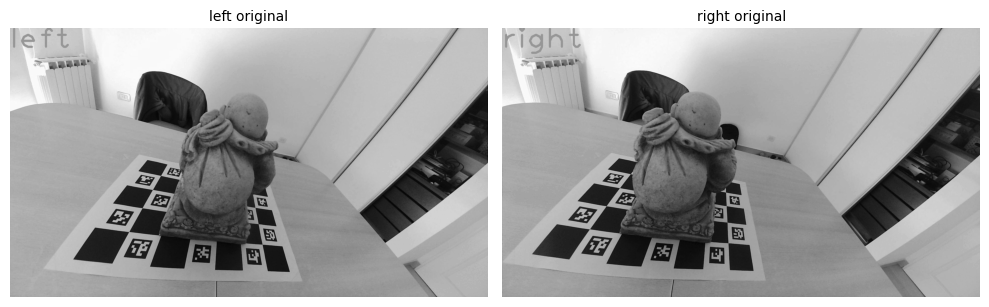

In [31]:

fig, axes = show_images([
    left_image, right_image
], [
    "left original", "right original"
], show=False)



In [32]:

import pickle
import os

stereo_calib_file = os.path.join("datasets","stereo_budha_charuco", "stereo_calibration.pkl")
stereo_maps_file = os.path.join("datasets","stereo_budha_charuco", "stereo_rectification_maps.pkl")

print("reading stereo calibration results...")
with open(stereo_calib_file, "rb") as f:
    calibration = pickle.loads(f.read())
    
print("reading stereo rectification maps...")
with open(stereo_maps_file, "rb") as f:
    maps = pickle.loads(f.read())

reading stereo calibration results...
reading stereo rectification maps...


In [33]:
left_map_x, left_map_y = maps['left_map_x'], maps['left_map_y']
right_map_x, right_map_y = maps['right_map_x'], maps['right_map_y']

In [34]:
import glob, os
directory = os.path.join("datasets", "stereo_budha_charuco", "captures")
left_files_pattern = "*left*.jpg"
right_files_pattern = "*right*.jpg"


left_file_names = sorted(
    glob.glob(
        os.path.join(directory, left_files_pattern)
    ),
    key=numeric_sort
)

right_file_names = sorted(
    glob.glob(
        os.path.join(directory, right_files_pattern)
    ),
    key=numeric_sort
)

num_left = len(left_file_names)
num_right = len(right_file_names)

if  num_left != num_right:
    raise Exception(f"the number of files (left {num_left} / right{num_right}) doesn't match")

In [35]:


left_images_rectified = []
right_images_rectified = []

for left_file_name, right_file_name in zip(
    left_file_names, right_file_names
):

    print("processing", left_file_name, right_file_name)


    # read left and right images
    left_image = cv2.imread(left_file_name, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_file_name, cv2.IMREAD_GRAYSCALE)

    # apply rectification
    left_image_rectified = cv2.remap(left_image, left_map_x, left_map_y, cv2.INTER_LINEAR)
    right_image_rectified = cv2.remap(right_image, right_map_x, right_map_y, cv2.INTER_LINEAR)

    left_images_rectified.append(left_image_rectified)
    right_images_rectified.append(right_image_rectified)


    output_file = os.path.join("datasets", "stereo_budha_charuco","rectified","left", left_file_name)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    cv2.imwrite(output_file, left_image_rectified)


    output_file = os.path.join("datasets", "stereo_budha_charuco","rectified","right", right_file_name)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    cv2.imwrite(output_file, right_image_rectified)

    
    

processing datasets\stereo_budha_charuco\captures\left_0.jpg datasets\stereo_budha_charuco\captures\right_0.jpg
processing datasets\stereo_budha_charuco\captures\left_1.jpg datasets\stereo_budha_charuco\captures\right_1.jpg
processing datasets\stereo_budha_charuco\captures\left_2.jpg datasets\stereo_budha_charuco\captures\right_2.jpg
processing datasets\stereo_budha_charuco\captures\left_3.jpg datasets\stereo_budha_charuco\captures\right_3.jpg
processing datasets\stereo_budha_charuco\captures\left_4.jpg datasets\stereo_budha_charuco\captures\right_4.jpg
processing datasets\stereo_budha_charuco\captures\left_5.jpg datasets\stereo_budha_charuco\captures\right_5.jpg
processing datasets\stereo_budha_charuco\captures\left_6.jpg datasets\stereo_budha_charuco\captures\right_6.jpg
processing datasets\stereo_budha_charuco\captures\left_7.jpg datasets\stereo_budha_charuco\captures\right_7.jpg
processing datasets\stereo_budha_charuco\captures\left_8.jpg datasets\stereo_budha_charuco\captures\righ

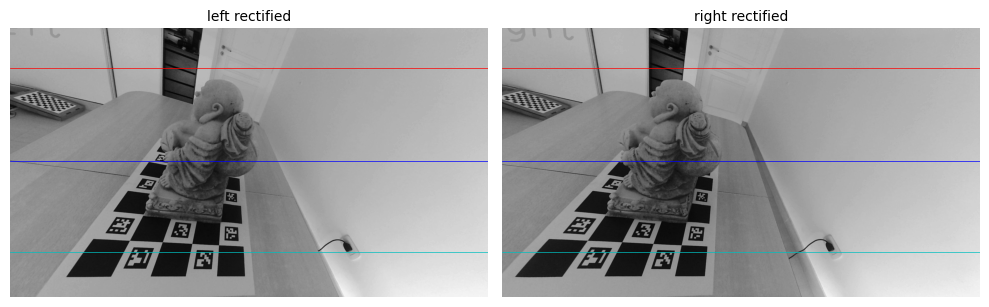

In [36]:
# tomemos un par estéreo
image_index = 6

# show images
fig, axes = show_images([
    left_images_rectified[image_index], right_images_rectified[image_index]
], [
    "left rectified", "right rectified"
], show=False)

for y, c in zip([160, 533, 900], ['r', 'b', 'c']):
    axes[0].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
    axes[1].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
plt.show()

DISPARIDAD


In [37]:
w, h = left_image.shape[1], left_image.shape[0]

fx = left_K[0][0]
fy = left_K[1][1]
cx0 = left_K[0][2]
cy0 = left_K[1][2]

baseline = np.linalg.norm(T)

In [38]:
# Cre Stereo

import cv2
import json
import numpy as np
from pathlib import Path

!pip install -qq onnxruntime

from utils.disparity.method_cre_stereo import CREStereo
from utils.disparity.methods import Calibration, InputPair, Config


calibration = Calibration(**{
    "width": w,
    "height": h,
    "baseline_meters": baseline / 1000,
    "fx": fx,
    "fy": fy,
    "cx0": cx0,
    "cx1": cx0,
    "cy": cy0,
    "depth_range": [0.05, 20.0],
    "left_image_rect_normalized": [0, 0, 1, 1]
})

^C


In [48]:
import os

models_path = "models"
if not os.path.exists(models_path):
    os.makedirs(models_path)

In [49]:
#models_path = Path.home() / ".cache" / "stereodemo" / "models"
models_path = Path(models_path)
pair = InputPair(left_image_rectified, right_image_rectified, calibration)
# pair = InputPair(left_image, right_image, calibration)
config = Config(models_path=models_path)

# params = {
#    "Shape": "1280x720",
#    "Mode": "combined",
#    "Iterations": 20
#}
method = CREStereo(config)

#method.parameters["Shape"].set_value("640x480")
method.parameters["Shape"].set_value("1280x720")
disparity = method.compute_disparity(pair)

models\crestereo_combined_iter5_720x1280.onnx


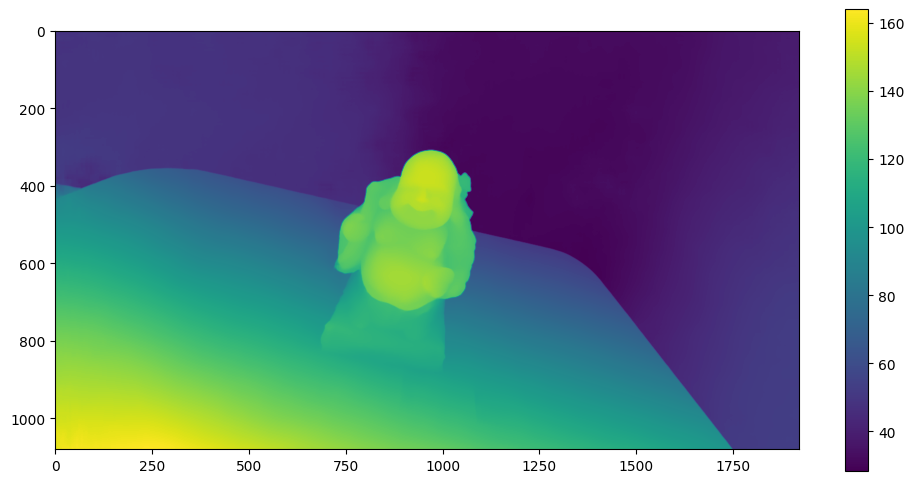

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(disparity.disparity_pixels)
plt.colorbar()
plt.show()

In [ ]:
def compute_depth(disparity_map, f, B, default=1000.0):

    # Crea una copia del mapa de disparidad
    disparity_map = disparity_map.copy()
    
    # Evita divisiones por cero o disparidades negativas (les asignamos el valor default)
    mask_invalid = (disparity_map <= 0)
    
    # Calcula la profundidad con la fórmula Z = f * B / disparidad
    depth_map = np.zeros_like(disparity_map, dtype=np.float32)
    depth_map[~mask_invalid] = (f * B) / disparity_map[~mask_invalid]
    
    # Asigna valor fijo a los puntos donde la disparidad es inválida
    depth_map[mask_invalid] = default
    
    return depth_map

In [ ]:
# disparity = np.load("disparity.npz")["arr_0"]
disparity_map = disparity.disparity_pixels

In [ ]:
f = left_K[0][0]
B = baseline = np.linalg.norm(T) 

depth = compute_depth(disparity_map, f, B)

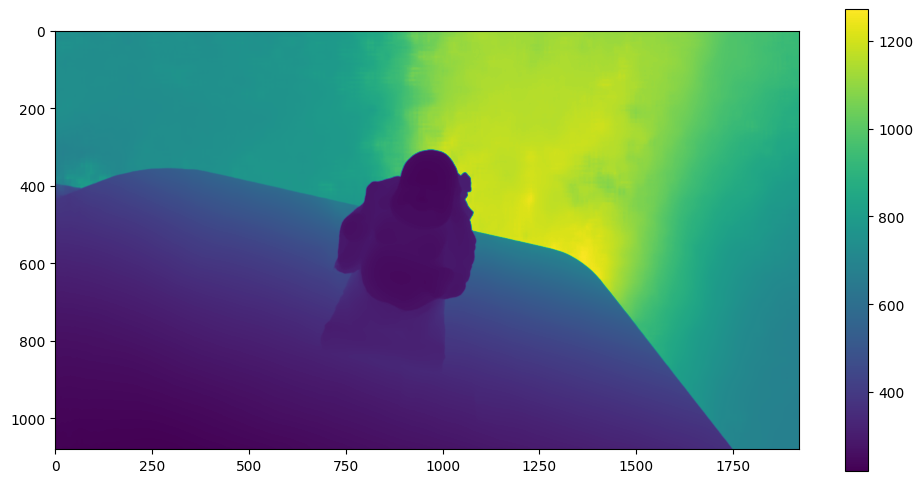

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(depth)
plt.colorbar()
plt.show()

In [ ]:
depth2 = depth.copy()
depth2[depth2 > 10000] = 10000 

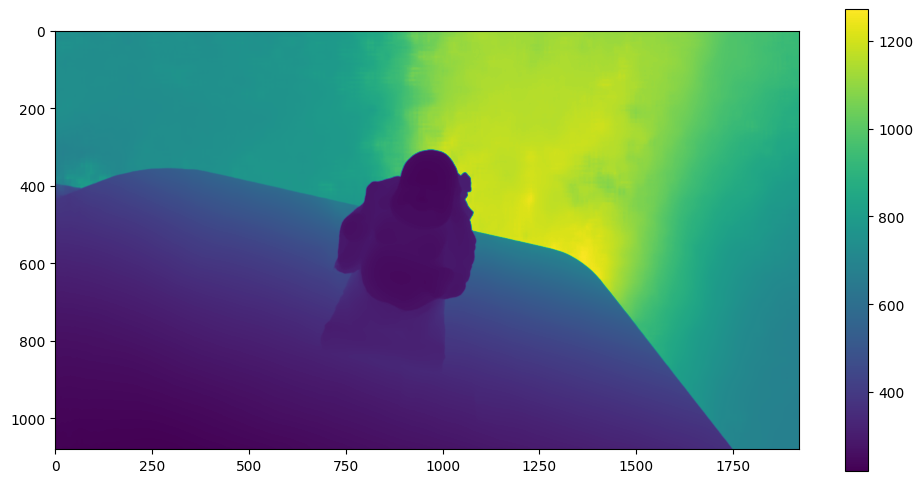

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(depth2)
plt.colorbar()
plt.show()

In [ ]:
def export_ply(archivo_ply, depth_map, img_color, f, cx, cy):
    """
    Exporta el mapa de profundidad y la imagen de color a un archivo .PLY.

    Parámetros:
        archivo_ply (str): Ruta del archivo de salida .PLY.
        depth_map (numpy.ndarray): Mapa de profundidad.
        img_color (numpy.ndarray): Imagen original en color.
        f (float): Distancia focal de la cámara (en píxeles).
        cx, cy (float): Coordenadas del centro óptico (en píxeles).
    """
    h, w = depth_map.shape
    with open(archivo_ply, 'w') as f_out:
        # Cabecera del archivo .PLY
        f_out.write('ply\n')
        f_out.write('format ascii 1.0\n')
        f_out.write(f'element vertex {h * w}\n')
        f_out.write('property float x\n')
        f_out.write('property float y\n')
        f_out.write('property float z\n')
        f_out.write('property uchar red\n')
        f_out.write('property uchar green\n')
        f_out.write('property uchar blue\n')
        f_out.write('end_header\n')

        for y in range(h):
            for x in range(w):
                Z = depth_map[y, x]
                if Z == 0:  # skippea píxeles con profundidad 0
                    continue
                
                # convierte coordenadas de píxel a coordenadas de mundo 3D
                X = (x - cx) * Z / f
                Y = (y - cy) * Z / f

                # color de la imagen original (en BGR)
                color = img_color[y, x]
                r, g, b = color[2], color[1], color[0]

                # escribie el punto 3D y su color al archivo PLY
                f_out.write(f'{X} {Y} {Z} {r} {g} {b}\n')

    print(f'Archivo .PLY guardado como {archivo_ply}')

In [ ]:
left_image_color = cv2.imread(left_image_file)

In [ ]:
left_image_color_rectified = cv2.remap(left_image_color, left_map_x, left_map_y, cv2.INTER_LINEAR)


In [ ]:
export_ply(
    "profundidad.ply",
    depth2,
    left_image_color_rectified,
    left_K[0, 0],
    left_K[0, 2],
    left_K[1, 2],

)

Archivo .PLY guardado como profundidad.ply


In [ ]:
# Visualizar .PLY en el notebook con Open3D
# pip install open3d si no está instalado
!pip install -q open3d

import open3d as o3d

pcd = o3d.io.read_point_cloud("profundidad.ply")
o3d.visualization.draw_geometries([pcd])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [50]:
from pathlib import Path
from utils.cre_utils import pair_rectified, make_cre, run_cre_on_pair


BASE        = Path("datasets/stereo_budha_charuco")
LEFT_ROOT   = BASE / "rectified" / "left"
RIGHT_ROOT  = BASE / "rectified" / "right"
OUT_DISP    = BASE / "disp"; OUT_DISP.mkdir(parents=True, exist_ok=True)

# Emparejar pares
left_files, right_files, idxs = pair_rectified(LEFT_ROOT, RIGHT_ROOT)
print(f"Pares encontrados: {len(idxs)}")
if idxs:
    print("Ejemplo:", left_files[0], "<->", right_files[0])

# Instanciar CREStereo una vez
cre = make_cre(Path(models_path), shape="1280x720")  # ajustá la shape si hace falta

# Loop y guardar
for lf, rf, idx in zip(left_files, right_files, idxs):
    res = run_cre_on_pair(cre, calibration, lf, rf, OUT_DISP, idx, preview=True)
    if not res["ok"]:
        print(f"[{idx}] WARN:", res["msg"])
        continue
    print(f"[{idx}] cover={res['cover_pct']:.1f}%  "
          f"disp[min,mean,max]=[{res['min']:.2f},{res['mean']:.2f},{res['max']:.2f}]  "
          f"-> {Path(res['npz']).name}")


Pares encontrados: 21
Ejemplo: datasets\stereo_budha_charuco\rectified\left\datasets\stereo_budha_charuco\captures\left_0.jpg <-> datasets\stereo_budha_charuco\rectified\right\datasets\stereo_budha_charuco\captures\right_0.jpg
models\crestereo_combined_iter5_720x1280.onnx
[0] cover=100.0%  disp[min,mean,max]=[21.42,91.37,209.92]  -> disp_0.npz
models\crestereo_combined_iter5_720x1280.onnx
[1] cover=100.0%  disp[min,mean,max]=[23.82,88.98,192.00]  -> disp_1.npz
models\crestereo_combined_iter5_720x1280.onnx
[2] cover=100.0%  disp[min,mean,max]=[28.77,84.83,186.03]  -> disp_2.npz
models\crestereo_combined_iter5_720x1280.onnx
[3] cover=100.0%  disp[min,mean,max]=[26.28,77.77,181.81]  -> disp_3.npz
models\crestereo_combined_iter5_720x1280.onnx
[4] cover=100.0%  disp[min,mean,max]=[12.51,79.16,182.23]  -> disp_4.npz
models\crestereo_combined_iter5_720x1280.onnx
[5] cover=100.0%  disp[min,mean,max]=[13.97,69.97,173.90]  -> disp_5.npz
models\crestereo_combined_iter5_720x1280.onnx
[6] cover=100

In [ ]:
import cv2 as cv
import open3d as o3d
import json
import numpy as np
from code_examples.charuco_example import aruco
from pathlib import Path

def estimate_pose_cv(img, board, detection, calibration):

    K, dist_coeffs = calibration
    corners = detection['corners']
    ids = detection['ids']

    # para encontrar la pose, OpenCV recomienda usar interpolateCornersCharuco
    # para estimar donde están los corners del tablero
    # luego busca con precisión de sub-píxel los corners y devuelve los resultados mejorados
    interpolation = cv.aruco.interpolateCornersCharuco(
        markerCorners=corners,
        markerIds=ids,
        image=img,
        board=board
    )
    # el resultado es la cantidad de corners que pudo interpolar
    # las posiciones de los corners interpolados y los ids correspondientes.
    num, ch_corners, ch_ids = interpolation
    if num < 4:
        print ("no se pudo interpolar la pose.")
        return False, None, None
    # la librería devuelve la pose usando la función estimatePoseCharucoBoard
    pose = cv.aruco.estimatePoseCharucoBoard(
        ch_corners,
        ch_ids,
        board,
        K,
        dist_coeffs,
        np.empty(1),
        np.empty(1)
    )
    ok, rv, tv = pose

    return pose

# Carpetas
LEFT_DIR = Path("datasets/stereo_budha_charuco/rectified/left")
OUT_DIR  = Path("datasets/stereo_budha_charuco/out"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# creo el charuco board
use_dict = cv2.aruco.DICT_6X6_250
squares_x=5
squares_y=7
square_length=52.6
marker_length=31.3


board = aruco.create_charuco_board(
    squares_x,
    squares_y,
    square_length,
    marker_length,
    use_dict
)

# cargo datos de rectificacion

S = np.load("datasets/stereo_budha_charuco/rectified/stereo_maps.npz", allow_pickle=True)
R1, R2, P1, P2, Q = S["R1"], S["R2"], S["P1"], S["P2"], S["Q"]
validRoi1, validRoi2 = tuple(S["validRoi1"]), tuple(S["validRoi2"])
left_map_x, left_map_y = S["left_map_x"], S["left_map_y"]
right_map_x, right_map_y = S["right_map_x"], S["right_map_y"]
image_size = tuple(S["image_size"])

# Intrínsecos para imágenes RECTIFICADAS:
K = P1[:3, :3]
dist_coeffs = None
calibration = (K, dist_coeffs)   # si tu helper lo espera así

# Utilidad: guardar pose a JSON
def save_pose_json(path, rvec, tvec):
    R,_ = cv2.Rodrigues(rvec)
    payload = {
        "rvec": rvec.reshape(-1).tolist(),
        "tvec": tvec.reshape(-1).tolist(),
        "R":    R.tolist()
    }
    path.write_text(json.dumps(payload, indent=2))

# Iterar izquierdas (ajustá extensiones si hace falta)
left_paths = sorted(list(LEFT_DIR.glob("*.jpg")))
ok_count, det_fail, pose_fail = 0, 0, 0

for Lp in left_paths:
    img = cv2.imread(str(Lp))
    if img is None:
        print(f"[WARN] No pude leer {Lp}"); 
        continue

    # 1) Detección (tu helper del módulo de la materia)
    detection = aruco.detect_charuco_markers(img, board)
    if not detection or detection.get("ids") is None or len(detection["ids"]) == 0:
        det_fail += 1
        print(f"[WARN] Sin detección en {Lp.name}")
        continue

    # 2) Pose (tu helper con homografía)
    ok, rvec, tvec = aruco.estimate_camera_pose_with_homography(img, board, detection, calibration)
    if not ok:
        pose_fail += 1
        print(f"[WARN] Sin pose en {Lp.name}")
        continue

    # 3) Evidencia: dibujar detección y ejes (ejes más cortos para que entren)
    vis = aruco.draw_aruco_results(img.copy(), detection, size=3)
    cv2.drawFrameAxes(vis, K, dist_coeffs, rvec, tvec, square_length * 1.5)

    # 4) Guardar JSON + PNG con el mismo índice que la imagen
    idx = Lp.stem.split("")[-1] if "" in Lp.stem else Lp.stem
    save_pose_json(OUT_DIR / f"pose_{idx}.json", rvec, tvec)
    cv2.imwrite(str(OUT_DIR / f"pose_{idx}.png"), vis)
    ok_count += 1

print(f"[OK] Poses guardadas: {ok_count}  | sin detección: {det_fail}  | sin pose: {pose_fail}")

In [43]:
import numpy as np
import cv2 as cv
from pathlib import Path

from utils.depth_from_disp_utils import (
    load_fx_baseline, pair_left_disp, load_disp_npz_anykey, save_depth_preview
)

# ---- rutas ----
BASE      = Path("datasets/stereo_budha_charuco")
LEFT_ROOT = BASE / "rectified" / "left"
DISP_DIR  = BASE / "disp"
DEPTH_DIR = BASE / "depth"; DEPTH_DIR.mkdir(parents=True, exist_ok=True)
MAPS_PKL  = BASE / "stereo_rectification_maps.pkl"

# calib 
fx, B_m, _, _ = load_fx_baseline(MAPS_PKL)
print(f"fx={fx:.1f} px   B={B_m:.4f} m")

#  emparejar 
left_files, disp_files, idxs = pair_left_disp(LEFT_ROOT, DISP_DIR)
print(f"Pares L+disp encontrados: {len(idxs)}")

# loop principal 
total_valid = 0
for lf, df, idx in zip(left_files, disp_files, idxs):
    # resolvemos forma objetivo con la left
    img = cv.imread(str(lf), cv.IMREAD_COLOR)
    if img is None:
        print(f"[{idx}] no pude leer {lf.name} → salto"); 
        continue
    h, w = img.shape[:2]

    # disparidad → depth (m)
    disp = load_disp_npz_anykey(df)
    if disp.shape != (h, w):
        disp = cv.resize(disp, (w, h), interpolation=cv.INTER_NEAREST)

    depth = compute_depth(disp, fx, B_m, default=np.nan)

    # guardar
    np.savez_compressed(DEPTH_DIR / f"depth_{idx}.npz", depth=depth)
    save_depth_preview(depth, DEPTH_DIR / f"depth_{idx}.png")

    # stats
    valid = np.isfinite(depth) & (depth > 0)
    total_valid += int(valid.sum())
    if valid.any():
        zmin = float(np.nanmin(depth[valid]))
        zmean = float(np.nanmean(depth[valid]))
        zmax = float(np.nanmax(depth[valid]))
    else:
        zmin = zmean = zmax = float("nan")
    print(f"[{idx}] valid={int(valid.sum())}/{depth.size}  "
          f"Z[min,mean,max]=[{zmin:.3f},{zmean:.3f},{zmax:.3f}] m  -> depth_{idx}.npz")

print("TOTAL píxeles con profundidad válida:", total_valid)


fx=603.0 px   B=0.0600 m
Pares L+disp encontrados: 21
[0] valid=2073600/2073600  Z[min,mean,max]=[0.172,0.584,1.708] m  -> depth_0.npz
[1] valid=2073600/2073600  Z[min,mean,max]=[0.188,0.581,1.476] m  -> depth_1.npz
[2] valid=2073600/2073600  Z[min,mean,max]=[0.194,0.575,1.217] m  -> depth_2.npz
[3] valid=2073600/2073600  Z[min,mean,max]=[0.199,0.649,1.384] m  -> depth_3.npz
[4] valid=2073600/2073600  Z[min,mean,max]=[0.198,0.668,2.142] m  -> depth_4.npz
[5] valid=2073600/2073600  Z[min,mean,max]=[0.208,0.786,2.454] m  -> depth_5.npz
[6] valid=2073600/2073600  Z[min,mean,max]=[0.201,0.846,2.918] m  -> depth_6.npz
[7] valid=2073600/2073600  Z[min,mean,max]=[0.192,0.952,3.490] m  -> depth_7.npz
[8] valid=2073522/2073600  Z[min,mean,max]=[0.186,1.006,1049.264] m  -> depth_8.npz
[9] valid=2073600/2073600  Z[min,mean,max]=[0.191,0.887,3.168] m  -> depth_9.npz
[10] valid=2073600/2073600  Z[min,mean,max]=[0.171,0.861,2.807] m  -> depth_10.npz
[11] valid=2073600/2073600  Z[min,mean,max]=[0.203

In [42]:
# compute_corners_disparity.py
from pathlib import Path
import cv2 as cv  # solo para asegurar disponibilidad
from utils.checker_disp_utils import list_pair_indices, process_pair

# Rutas
BASE      = Path(r"datasets/stereo_budha_charuco")          # ajusta si es necesario
LEFT_DIR  = BASE / "rectified" / "left"
RIGHT_DIR = BASE / "rectified" / "right"
DISP_DIR  = Path(r"C:\Users\andyd\Udesa\Vision Artificial\TP2_Reconstruccion_3D\datasets\stereo_budha_charuco\disp")
OUT_DIR   = BASE / "corners_disparity_pairs"

# Parámetros
CB_COLS, CB_ROWS = 10, 7
DO_LK = True

pairs = list_pair_indices(LEFT_DIR, RIGHT_DIR)
print(f"DISP_DIR: {DISP_DIR}")
print(f"Procesaré {len(pairs)} pares…")

for lpath, rpath, idx in pairs:
    process_pair(lpath, rpath, idx, disp_dir=DISP_DIR, out_dir=OUT_DIR,
                 cb_cols=CB_COLS, cb_rows=CB_ROWS, do_lk=DO_LK)

print("Listo.")


DISP_DIR: C:\Users\andyd\Udesa\Vision Artificial\TP2_Reconstruccion_3D\datasets\stereo_budha_charuco\disp
Procesaré 21 pares…
[0] corners=70  valid_map=65  valid_lk=46  |  |d_map - d_LK| mean=32.56px → corners_disp_pair_0.csv
[1] corners=70  valid_map=46  valid_lk=23  |  |d_map - d_LK| mean=56.50px → corners_disp_pair_1.csv
[2] corners=70  valid_map=43  valid_lk=21  |  |d_map - d_LK| mean=46.20px → corners_disp_pair_2.csv
[3] corners=70  valid_map=39  valid_lk=21  |  |d_map - d_LK| mean=53.78px → corners_disp_pair_3.csv
[4] corners=70  valid_map=60  valid_lk=45  |  |d_map - d_LK| mean=44.29px → corners_disp_pair_4.csv
[5] corners=70  valid_map=50  valid_lk=25  |  |d_map - d_LK| mean=31.24px → corners_disp_pair_5.csv
[6] corners=70  valid_map=70  valid_lk=48  |  |d_map - d_LK| mean=24.41px → corners_disp_pair_6.csv
[7] corners=70  valid_map=68  valid_lk=49  |  |d_map - d_LK| mean=27.26px → corners_disp_pair_7.csv
[8] corners=70  valid_map=39  valid_lk=30  |  |d_map - d_LK| mean=24.34px 

In [39]:
import numpy as np
import cv2 as cv
import open3d as o3d
from pathlib import Path

from utils.stereo_pcd_utils import (
    Calib, calib_from_obj, list_indices, load_left, load_disp_npz,
    compute_depth, depth_to_pcd, build_K, charuco_pose_on_left,
    crop_with_obb, denoise_statistical
)

# funciones de la cátedra
from utils.charuco_utils import (
    create_charuco_board,
    detect_charuco_markers,
    estimate_camera_pose_with_homography,
    draw_charuco_markers,  # opcional solo para debug
)


calib = calib_from_obj(calibration)
print(f"[Calib] fx={calib.fx:.2f}  B={calib.baseline_m:.5f} m  (W,H)=({calib.width},{calib.height})  cx={calib.cx:.1f} cy={calib.cy:.1f}")
K = build_K(calib)

#  Rutas 
BASE     = Path(r"C:\Users\andyd\Udesa\Vision Artificial\TP2_Reconstruccion_3D\datasets\stereo_budha_charuco")
LEFT_DIR = BASE / "rectified" / "left"
DISP_DIR = BASE / "disp"
OUT_DIR  = BASE / "pcd_charuco_boxed_calib"
DBG_DIR  = BASE / "debug_charuco"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DBG_DIR.mkdir(parents=True, exist_ok=True)

# Parámetros de tablero y recorte 
DICT = cv.aruco.DICT_6X6_250
SQUARES_X, SQUARES_Y = 5, 7
SQUARE_LENGTH = 0.04
MARKER_LENGTH = 0.02

BOX_EXTENT = (0.45, 0.35, 0.60)
Z_CLIP     = (0.05, 5.0)
NB_NEI, STD_RATIO = 20, 1.5

# Tablero
board = create_charuco_board(SQUARES_X, SQUARES_Y, SQUARE_LENGTH, MARKER_LENGTH, DICT)

#  Proceso por frames 
idxs = list_indices(DISP_DIR)
print(f"Procesaré {len(idxs)} frames…")

for i in idxs:
    img = load_left(LEFT_DIR, i)
    if img is None:
        print(f"[{i}] ⚠️ no encuentro left_{i}.jpg → salto")
        continue

    if (img.shape[1], img.shape[0]) != (calib.width, calib.height):
        img = cv.resize(img, (calib.width, calib.height), interpolation=cv.INTER_AREA)

    D = load_disp_npz(DISP_DIR, i, target_shape=(calib.height, calib.width))
    Z = compute_depth(D, calib.fx, calib.baseline_m, default=np.nan)

    pcd = depth_to_pcd(Z, img, calib.fx, calib.cx, calib.cy, z_min=Z_CLIP[0], z_max=Z_CLIP[1])
    if len(pcd.points) == 0:
        print(f"[{i}] ⚠️ 0 puntos → salto")
        continue

    ok, R, t = charuco_pose_on_left(img, board, K, detect_charuco_markers, estimate_camera_pose_with_homography)
    if ok:
        pcd = crop_with_obb(pcd, R, t, BOX_EXTENT, lift_m=0.02)
        try:
            overlay = draw_charuco_markers(img, detect_charuco_markers(img, board))
            cv.imwrite(str(DBG_DIR / f"left_{i}_charuco_overlay.jpg"), overlay)
        except Exception:
            pass
    else:
        print(f"[{i}] ⚠️ ChArUco NO detectado, guardo nube completa")

    pcd = denoise_statistical(pcd, NB_NEI, STD_RATIO)

    out_ply = OUT_DIR / f"buda_charuco_box_calib_{i}.ply"
    o3d.io.write_point_cloud(str(out_ply), pcd, write_ascii=False)
    print(f"[{i}] OK → {out_ply.name} ({len(pcd.points)} pts)")

print("Listo. PLYs en:", OUT_DIR)
print("Overlays:", DBG_DIR)


[Calib] fx=600.57  B=0.05996 m  (W,H)=(1920,1080)  cx=950.8 cy=540.6
Procesaré 21 frames…
[0] OK → buda_charuco_box_calib_0.ply (321780 pts)
[1] OK → buda_charuco_box_calib_1.ply (391624 pts)
[2] OK → buda_charuco_box_calib_2.ply (380151 pts)
[3] OK → buda_charuco_box_calib_3.ply (384887 pts)
[4] OK → buda_charuco_box_calib_4.ply (426590 pts)
[5] OK → buda_charuco_box_calib_5.ply (390774 pts)
[6] OK → buda_charuco_box_calib_6.ply (420094 pts)
[7] OK → buda_charuco_box_calib_7.ply (482819 pts)
[8] OK → buda_charuco_box_calib_8.ply (454074 pts)
[9] OK → buda_charuco_box_calib_9.ply (494801 pts)
[10] OK → buda_charuco_box_calib_10.ply (518471 pts)
[11] OK → buda_charuco_box_calib_11.ply (477505 pts)
[12] OK → buda_charuco_box_calib_12.ply (433760 pts)
[13] OK → buda_charuco_box_calib_13.ply (452019 pts)
[14] OK → buda_charuco_box_calib_14.ply (325189 pts)
[15] OK → buda_charuco_box_calib_15.ply (209269 pts)
[16] OK → buda_charuco_box_calib_16.ply (173276 pts)
[17] OK → buda_charuco_box_ca

In [40]:
from pathlib import Path
from utils.icp_refine import Paths, ICPConfig, run_pipeline

# rutas
BASE = Path(r"C:\Users\andyd\Udesa\Vision Artificial\TP2_Reconstruccion_3D\datasets\stereo_budha_charuco")
paths = Paths.from_base(BASE)

# Parámetros icp
cfg = ICPConfig(
    icp_levels=(0.02, 0.01, 0.005),
    icp_iters=(60, 80, 100),
    voxel_seed=0.006,
    voxel_fuse=0.003,
    nb_neighbors=20,
    std_ratio=1.5,
    min_points=2000,
)

run_pipeline(paths, cfg, make_mesh=True, visualize=True)


[0] ok (321780 pts)
[1] ok (391624 pts)
[2] ok (380151 pts)
[3] ok (384887 pts)
[4] ok (426590 pts)
[5] ok (390774 pts)
[6] ok (420094 pts)
[7] ok (482819 pts)
[8] ok (454074 pts)
[9] ok (494801 pts)
[10] ok (518471 pts)
[11] ok (477505 pts)
[12] ok (433760 pts)
[13] ok (452019 pts)
[14] ok (325189 pts)
[15] ok (209269 pts)
[16] ok (173276 pts)
[17] ok (190673 pts)
[18] ok (252256 pts)
[19] ok (332501 pts)
[20] ok (312543 pts)
fusión 1/20 → total 713,404
fusión 2/20 → total 1,093,555
fusión 3/20 → total 1,478,442
fusión 4/20 → total 1,905,032
fusión 5/20 → total 2,295,806
fusión 6/20 → total 2,715,900
fusión 7/20 → total 3,198,719
fusión 8/20 → total 3,652,793
fusión 9/20 → total 4,147,594
fusión 10/20 → total 4,666,065
fusión 11/20 → total 5,143,570
fusión 12/20 → total 5,577,330
fusión 13/20 → total 6,029,349
fusión 14/20 → total 6,354,538
fusión 15/20 → total 6,563,807
fusión 16/20 → total 6,737,083
fusión 17/20 → total 6,927,756
fusión 18/20 → total 7,180,012
fusión 19/20 → total 7

(PointCloud with 94950 points.,
 TriangleMesh with 94950 points and 64074 triangles.)

In [ ]:
import numpy as np
import open3d as o3d
from pathlib import Path

# RUTA de entrada
BASE    = Path(r"C:\Users\andyd\Udesa\Vision Artificial\TP2_Reconstruccion_3D\datasets\stereo_budha_charuco")
IN_PLY  = BASE / "buda_refined_icp_vox.ply" 
OUT_DIR = BASE / "post"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PLY = OUT_DIR / "buda_no_floor.ply"

# Parámetros
RANSAC_DIST   = 0.003    # 3 mm: tolerancia para hallar el plano
PLANE_THRESH  = 0.006    # 6 mm: quito solo puntos MUY cerca del plano
DBSCAN_EPS    = 0.012    # 12 mm (opcional)
DBSCAN_MINPTS = 50

print(f"Leyendo: {IN_PLY}")
pc = o3d.io.read_point_cloud(str(IN_PLY))
N0 = len(pc.points)
assert N0 > 0, "La nube está vacía."

# Detectar plano (tablero/piso) con RANSAC
plane_model, inliers = pc.segment_plane(distance_threshold=RANSAC_DIST,
                                        ransac_n=3, num_iterations=2000)
a, b, c, d = plane_model
normal = np.array([a, b, c], dtype=np.float64)
norm_n = np.linalg.norm(normal)
if norm_n < 1e-9:
    raise RuntimeError("Normal del plano degenerada")
normal /= norm_n
d_norm = d / norm_n

print(f"Plano: n={normal}, d={d_norm:.4f}  |  inliers={len(inliers)} de {N0}")

# Quitar puntos pegados al plano (|dist| < PLANE_THRESH)
P = np.asarray(pc.points)
if len(pc.colors):
    C = np.asarray(pc.colors)
else:
    C = None

# distancia con signo (m), positiva en dirección de la normal
dist = (P @ normal) + d_norm

mask_keep = np.abs(dist) > PLANE_THRESH
P1 = P[mask_keep]
C1 = C[mask_keep] if C is not None else None
print(f"Tras quitar plano cercano: {len(P1)} puntos (de {N0})")

pc1 = o3d.geometry.PointCloud()
pc1.points = o3d.utility.Vector3dVector(P1)
if C1 is not None:
    pc1.colors = o3d.utility.Vector3dVector(C1)

# cluster mayor por si quedan restos del tablero
if len(P1) > 0:
    labels = np.array(pc1.cluster_dbscan(eps=DBSCAN_EPS, min_points=DBSCAN_MINPTS, print_progress=False))
    if labels.size > 0 and labels.max() >= 0:
        # encuentra el índice del cluster más grande
        counts = [(labels == k).sum() for k in range(labels.max()+1)]
        kmax = int(np.argmax(counts))
        idx = np.where(labels == kmax)[0]
        pc1 = pc1.select_by_index(idx)
        print(f"DBSCAN: clusters={labels.max()+1}, quedo con k={kmax}, N={len(pc1.points)}")
    else:
        print("DBSCAN: no formó clusters útiles; conservo todo.")

# Limpieza
if len(pc1.points) == 0:
    raise RuntimeError("Quedaron 0 puntos tras quitar el plano.")

pc1, _ = pc1.remove_statistical_outlier(nb_neighbors=20, std_ratio=1.2)
o3d.io.write_point_cloud(str(OUT_PLY), pc1, write_ascii=False)
print(f"OK -> {OUT_PLY}  ({len(pc1.points)} pts)")

# Visualización 
o3d.visualization.draw_geometries([pc1], window_name="Buda sin piso")


Leyendo: C:\Users\andyd\Udesa\Vision Artificial\TP2_Reconstruccion_3D\datasets\stereo_budha_charuco\buda_refined_icp_vox.ply
Plano: n=[-0.00843575 -0.00987592  0.99991565], d=0.0137  |  inliers=39949 de 94950
Tras quitar plano cercano: 45679 puntos (de 94950)
DBSCAN: clusters=17, quedo con k=0, N=38639
OK -> C:\Users\andyd\Udesa\Vision Artificial\TP2_Reconstruccion_3D\datasets\stereo_budha_charuco\post\buda_no_floor.ply  (35578 pts)
